# Stage 02 GCC to TDOA

这份 notebook 使用 single-reflection 稳定几何数据集，直接从 `gcc_phat + 3` 个麦间距离预测 `3` 个 TDOA。

In [1]:
from pathlib import Path
import json
import sys

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs an interpreter/kernel with torch installed. Please switch to your myenv Python before running it."
    ) from exc
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.gitignore').exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'python_impl').exists():
    raise RuntimeError(f'Failed to locate repo root from {NOTEBOOK_DIR}')

STAGE02_DIR = REPO_ROOT / 'python_impl' / 'experiments' / 'hypothesis_validation' / '02_source_localization_reflections'
SRC_DIR = STAGE02_DIR / 'src'
for path in (REPO_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from gcc_reflection_notebook_utils import build_gcc_reflection_bundle, train_gcc_to_tdoa_model

print('Repo root =', REPO_ROOT)
print('Stage02 dir =', STAGE02_DIR)

Repo root = z:\anc\distributed_anc_sim_py
Stage02 dir = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\02_source_localization_reflections


In [2]:
H5_PATH = STAGE02_DIR / 'data' / 'source_localization_single_reflection_l1_stable_v3_w2.h5'
RESULT_DIR = STAGE02_DIR / 'results' / 'gcc_to_tdoa_l1_stable_v3_w2'
LR = 1.0e-3
BATCH_SIZE = 128
EPOCHS = 40
SEED = 7
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('H5_PATH =', H5_PATH)
print('RESULT_DIR =', RESULT_DIR)
print('DEVICE =', DEVICE)

H5_PATH = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\02_source_localization_reflections\data\source_localization_single_reflection_l1_stable_v3_w2.h5
RESULT_DIR = z:\anc\distributed_anc_sim_py\python_impl\experiments\hypothesis_validation\02_source_localization_reflections\results\gcc_to_tdoa_l1_stable_v3_w2
DEVICE = cuda


In [3]:
bundle = build_gcc_reflection_bundle(H5_PATH)
print('geometry_filter_mode =', bundle.geometry_filter_mode)
print('min_triangle_area =', bundle.min_triangle_area)
print('max_jacobian_condition =', bundle.max_jacobian_condition)
print('max_triangle_angle_deg =', bundle.max_triangle_angle_deg)
print('near_ref_inside_threshold_m =', bundle.near_ref_inside_threshold_m)
print('source_region_rule_version =', bundle.source_region_rule_version)
print('rir_model =', bundle.rir_model)
print('air_attenuation_enabled =', bundle.air_attenuation_enabled)
print('air_attenuation_alpha_per_m =', bundle.air_attenuation_alpha_per_m)
print('reflection_profile_mix =', bundle.reflection_profile_mix)
print('profile_counts =', bundle.profile_counts)
print('split_sizes =', bundle.split_sizes)
print('removed train overlap =', bundle.train_overlap_removed)
print('gcc shape =', bundle.gcc_phat.shape)

geometry_filter_mode = stable
min_triangle_area = 0.25
max_jacobian_condition = 30.0
max_triangle_angle_deg = 120.0
near_ref_inside_threshold_m = 0.5
source_region_rule_version = stage01_stable_v3
rir_model = manual_2d_image_source_air
air_attenuation_enabled = True
air_attenuation_alpha_per_m = 0.03
reflection_profile_mix = {'single_reflection': 0.9, 'anechoic': 0.1}
profile_counts = {'anechoic': 593, 'single_reflection': 5407}
split_sizes = {'train': 3033, 'iid_val': 900, 'iid_test': 900, 'geom_val': 480, 'geom_test': 1203}
removed train overlap = 1167
gcc shape = (6000, 3, 257)


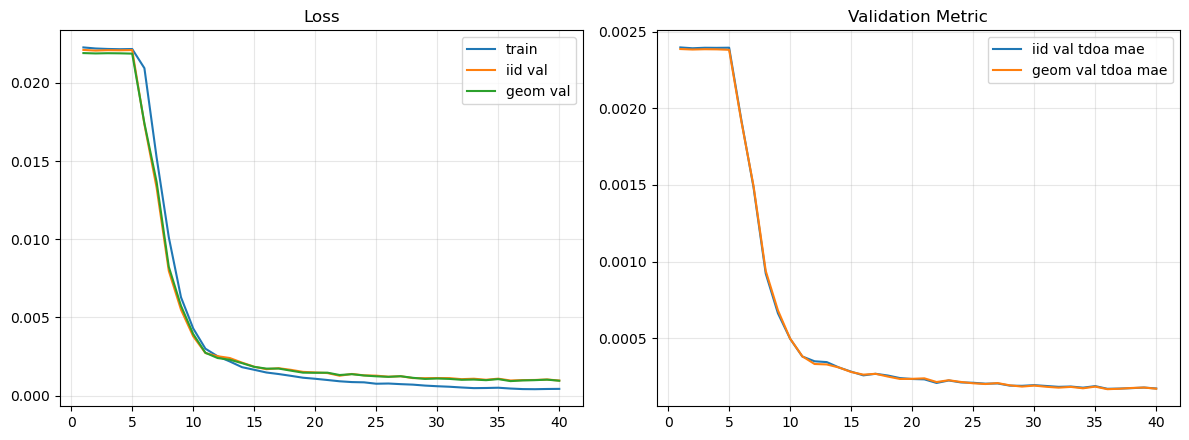

{
  "h5_path": "z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\02_source_localization_reflections\\data\\source_localization_single_reflection_l1_stable_v3_w2.h5",
  "best_epoch": 36,
  "epochs_requested": 40,
  "epochs_ran": 40,
  "checkpoint_path": "z:\\anc\\distributed_anc_sim_py\\python_impl\\experiments\\hypothesis_validation\\02_source_localization_reflections\\results\\gcc_to_tdoa_l1_stable_v3_w2\\best_model.pt",
  "target_parameterization": "normalized_lag_samples_2dof_reconstruct_3rd",
  "huber_delta_norm": 0.05,
  "bound_penalty_weight": 0.05,
  "scheduler_patience": 4,
  "scheduler_factor": 0.5,
  "scheduler_min_lr": 1e-06,
  "early_stop_patience": 12,
  "early_stop_min_delta": 0.0,
  "curriculum_mode": "none",
  "curriculum_stage1_ratio": 0.4,
  "curriculum_stage1_anechoic_boost": 6.0,
  "curriculum_stage1_epochs": 16,
  "aux_feature_mode": "pair_distance_norm",
  "aux_feature_dim": 3,
  "dropout_p": 0.1,
  "init_checkpoint_path": null,
  

In [4]:
summary = train_gcc_to_tdoa_model(
    bundle=bundle,
    result_dir=RESULT_DIR,
    lr=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=SEED,
    device=DEVICE,
    live_plot=True,
)
print(json.dumps(summary, ensure_ascii=False, indent=2))


loss_curves.png


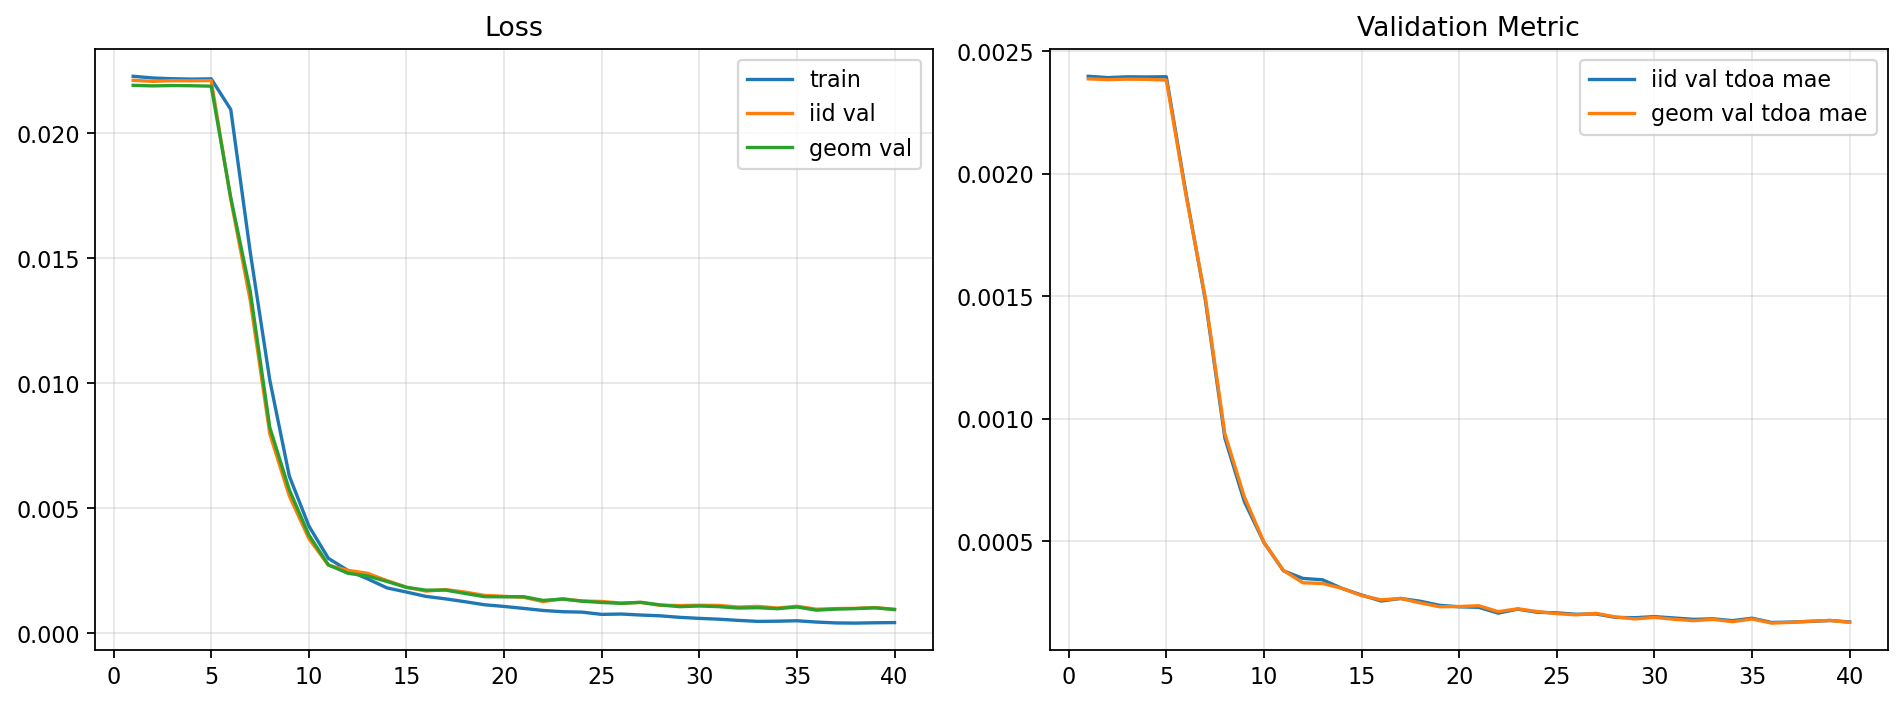


scatter_iid_test.png


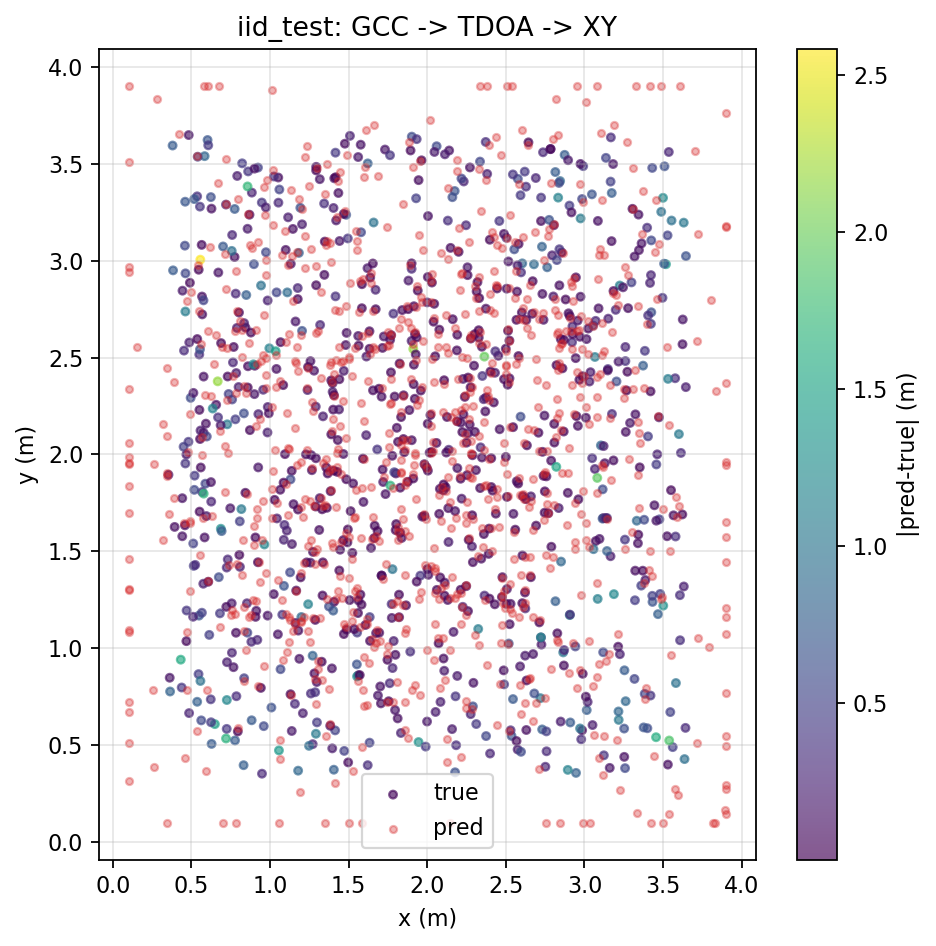


scatter_geom_test.png


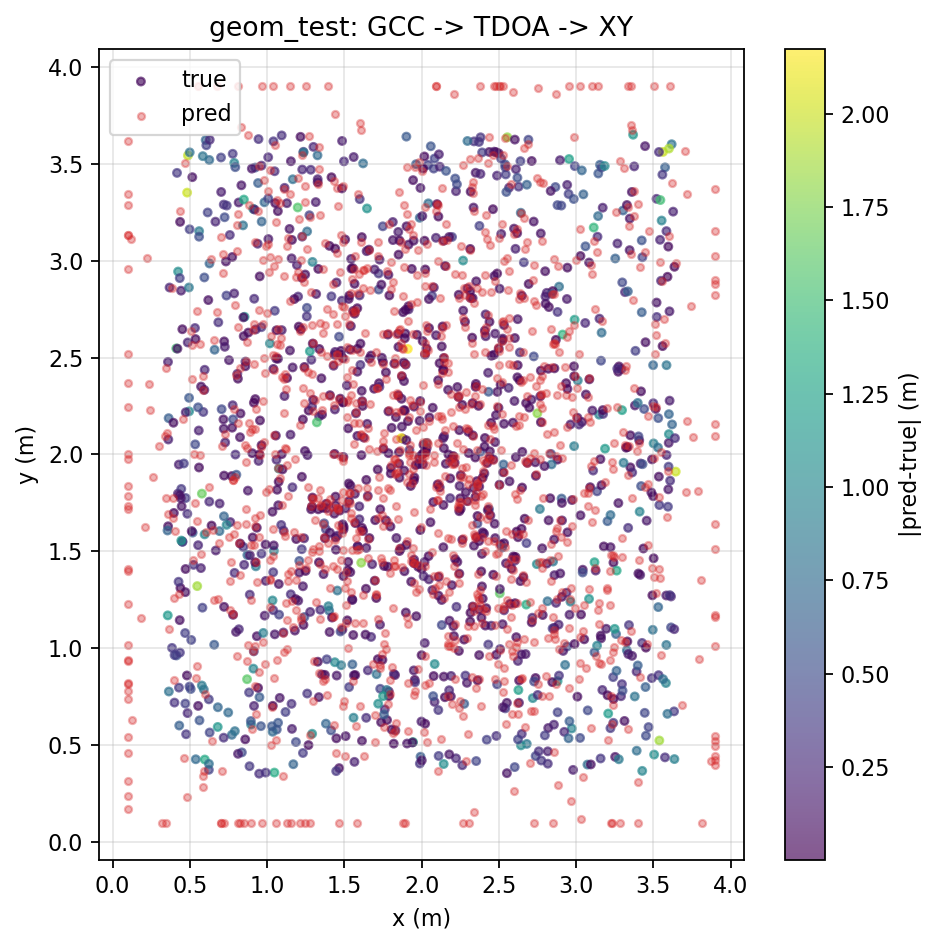

In [5]:
for name in ['loss_curves.png', 'scatter_iid_test.png', 'scatter_geom_test.png']:
    path = RESULT_DIR / name
    print(f'\n{name}')
    display(Image(filename=str(path)))